# NPU/GPU MatMul Profiling

In [ ]:
npu_result_path = "./npu_result_mm.csv"
gpu_result_path = "./gpu_result_mm.csv"

# result: {(N, D, M): (compile time, runtime, throughput (TOPS))}
def parse_result(result_path):
    results = {}
    with open(result_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            items = [item.strip() for item in line.split(",")]
            assert len(items) == 6
            shape_key = (int(items[0]), int(items[1]), int(items[2]))
            results[shape_key] = (int(items[3]), int(items[4]), float(items[5]))
    return results

npu_results = parse_result(npu_result_path)
gpu_results = parse_result(gpu_result_path)

# (k, 4096, 4096)
keys1 = [(1, 4096, 4096)] + [(i, 4096, 4096) for i in range(8, 4097, 8)]
npu_data1 = [npu_results[key] for key in keys1]
gpu_data1 = [gpu_results[key] for key in keys1]
# (4096, 4096, k)
keys2 = [(4096, 4096, 1)] + [(4096, 4096, i) for i in range(8, 4097, 8)]
npu_data2 = [npu_results[key] for key in keys2]
gpu_data2 = [gpu_results[key] for key in keys2]
# (k, 4096, 11008)
keys3 = [(1, 4096, 11008)] + [(i, 4096, 11008) for i in range(8, 4097, 8)]
npu_data3 = [npu_results[key] for key in keys3]
gpu_data3 = [gpu_results[key] for key in keys3]
# (11008, 4096, k)
keys4 = [(11008, 4096, 1)] + [(11008, 4096, i) for i in range(8, 4097, 8)]
npu_data4 = [npu_results[key] for key in keys4]
gpu_data4 = [gpu_results[key] for key in keys4]

## Compile time
### [k, 4096] * [4096, 4096] and [4096, 4096] * [4096, k]

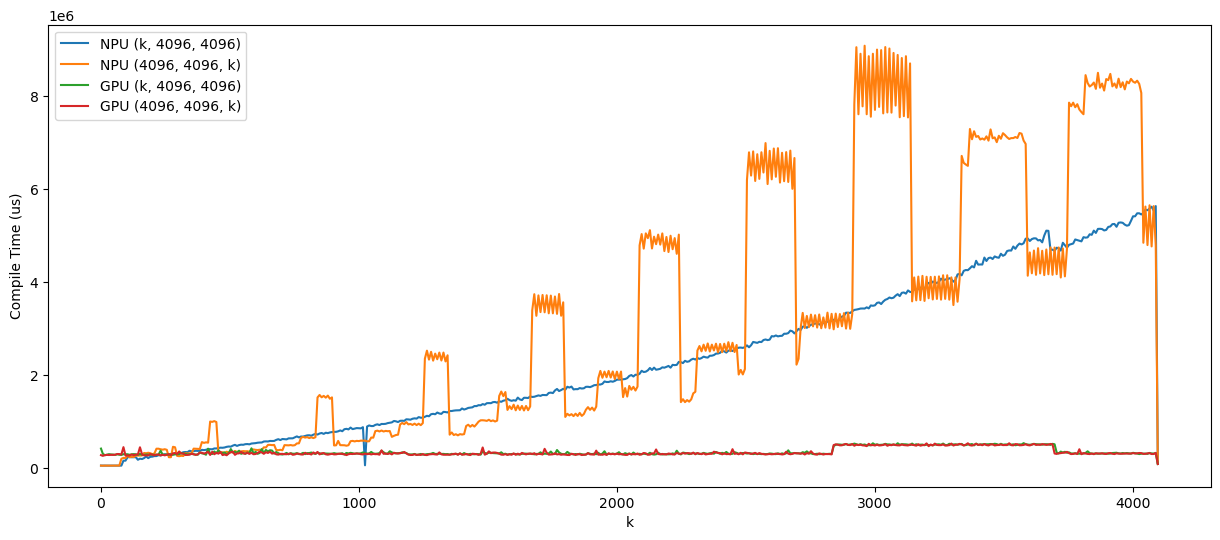

In [ ]:
import matplotlib.pyplot as plt
import numpy as np    

x = [k[0] for k in keys1]
npu_y1 = [d[0] for d in npu_data1]
npu_y2 = [d[0] for d in npu_data2]
gpu_y1 = [d[0] for d in gpu_data1]
gpu_y2 = [d[0] for d in gpu_data2]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npu_y1, label='NPU (k, 4096, 4096)')
ax.plot(x, npu_y2, label='NPU (4096, 4096, k)')
ax.plot(x, gpu_y1, label='GPU (k, 4096, 4096)')
ax.plot(x, gpu_y2, label='GPU (4096, 4096, k)')

ax.set_xlabel('k')
ax.set_ylabel('Compile Time (us)')
ax.legend()
plt.show()

### [k, 4096] * [4096, 11008] and [11008, 4096] * [4096, k]

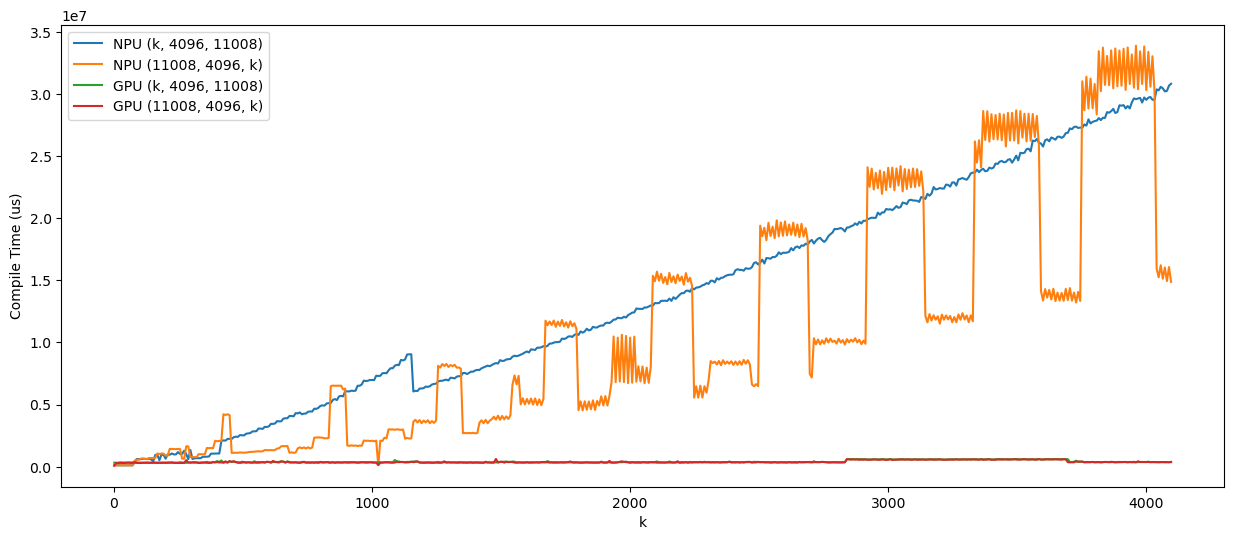

In [ ]:
x = [k[0] for k in keys3]
npu_y1 = [d[0] for d in npu_data3]
npu_y2 = [d[0] for d in npu_data4]
gpu_y1 = [d[0] for d in gpu_data3]
gpu_y2 = [d[0] for d in gpu_data4]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npu_y1, label='NPU (k, 4096, 11008)')
ax.plot(x, npu_y2, label='NPU (11008, 4096, k)')
ax.plot(x, gpu_y1, label='GPU (k, 4096, 11008)')
ax.plot(x, gpu_y2, label='GPU (11008, 4096, k)')
ax.set_xlabel('k')
ax.set_ylabel('Compile Time (us)')
ax.legend()
plt.show()

## Runtime
### [k, 4096] * [4096, 4096] and [4096, 4096] * [4096, k]

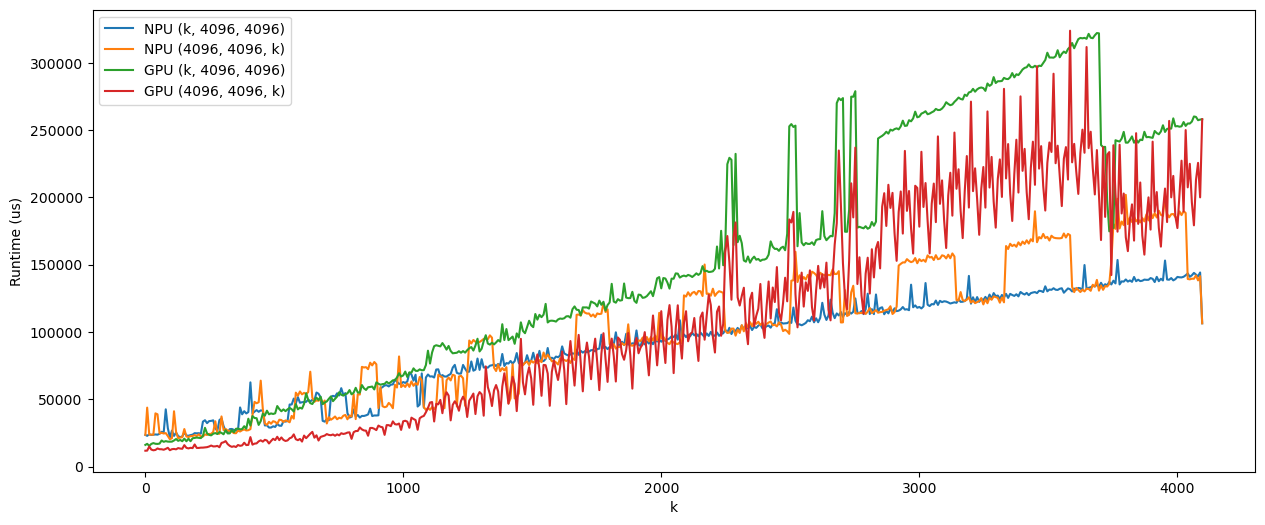

In [ ]:
npu_y1 = [d[1] for d in npu_data1]
npu_y2 = [d[1] for d in npu_data2]
gpu_y1 = [d[1] for d in gpu_data1]
gpu_y2 = [d[1] for d in gpu_data2]

# plot a line chart with common x and four lines with each y data
fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npu_y1, label='NPU (k, 4096, 4096)')
ax.plot(x, npu_y2, label='NPU (4096, 4096, k)')
ax.plot(x, gpu_y1, label='GPU (k, 4096, 4096)')
ax.plot(x, gpu_y2, label='GPU (4096, 4096, k)')
ax.set_xlabel('k')
ax.set_ylabel('Runtime (us)')
ax.legend()
plt.show()

### [k, 4096] * [4096, 11008] and [11008, 4096] * [4096, k]

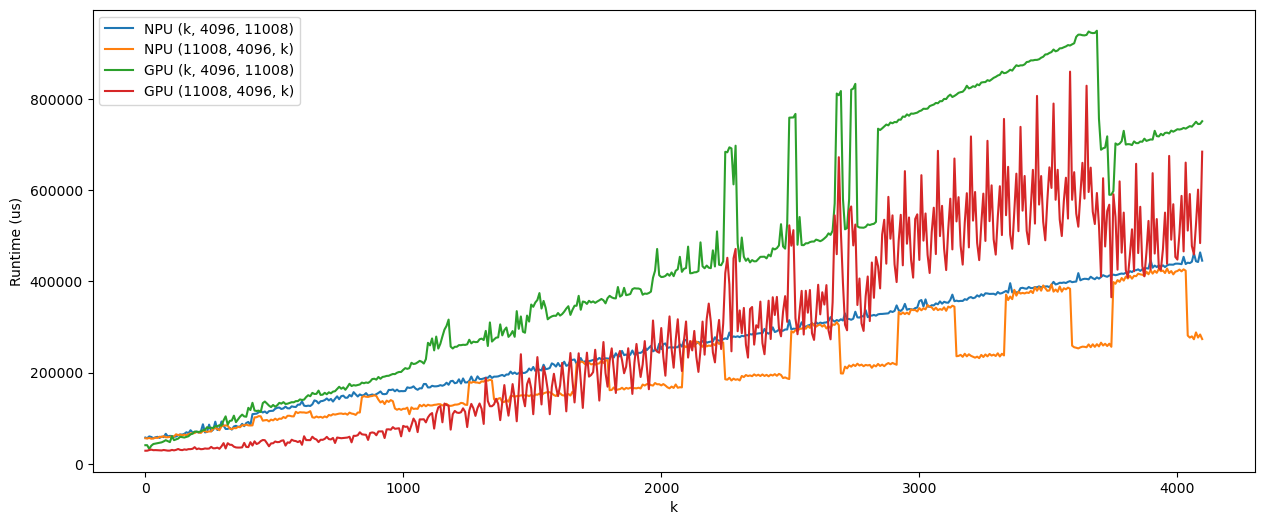

In [ ]:
npu_y1 = [d[1] for d in npu_data3]
npu_y2 = [d[1] for d in npu_data4]
gpu_y1 = [d[1] for d in gpu_data3]
gpu_y2 = [d[1] for d in gpu_data4]

fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npu_y1, label='NPU (k, 4096, 11008)')
ax.plot(x, npu_y2, label='NPU (11008, 4096, k)')
ax.plot(x, gpu_y1, label='GPU (k, 4096, 11008)')
ax.plot(x, gpu_y2, label='GPU (11008, 4096, k)')
ax.set_xlabel('k')
ax.set_ylabel('Runtime (us)')
ax.legend()
plt.show()

## Throughput (TOPS)
### [k, 4096] * [4096, 4096] and [4096, 4096] * [4096, k]

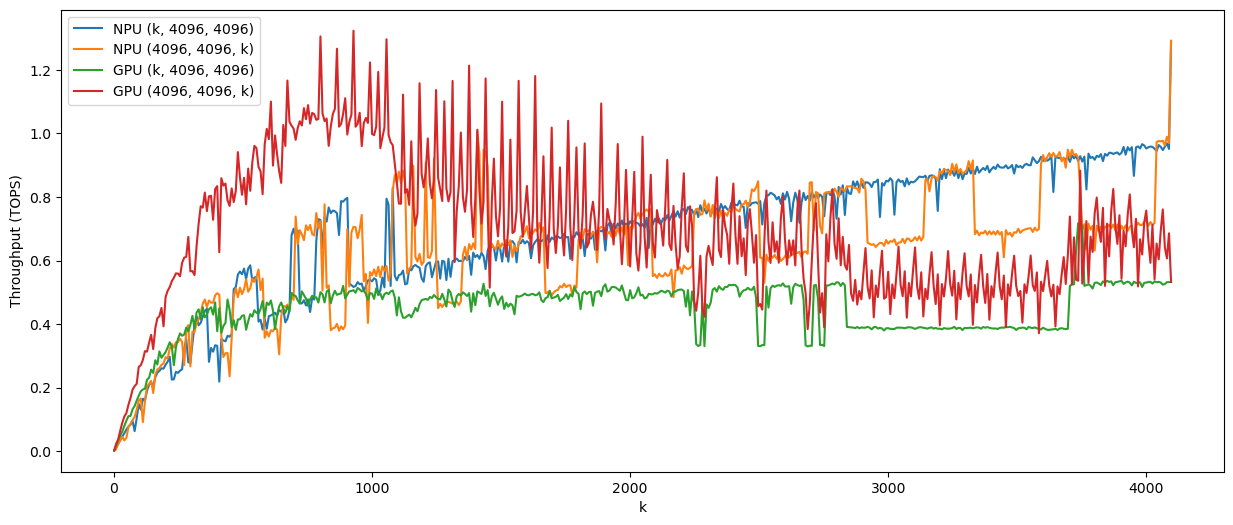

In [ ]:
npu_y1 = [d[2] for d in npu_data1]
npu_y2 = [d[2] for d in npu_data2]
gpu_y1 = [d[2] for d in gpu_data1]
gpu_y2 = [d[2] for d in gpu_data2]

fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npu_y1, label='NPU (k, 4096, 4096)')
ax.plot(x, npu_y2, label='NPU (4096, 4096, k)')
ax.plot(x, gpu_y1, label='GPU (k, 4096, 4096)')
ax.plot(x, gpu_y2, label='GPU (4096, 4096, k)')
ax.set_xlabel('k')
ax.set_ylabel('Throughput (TOPS)')
ax.legend()
plt.show()

### [k, 4096] * [4096, 11008] and [11008, 4096] * [4096, k]

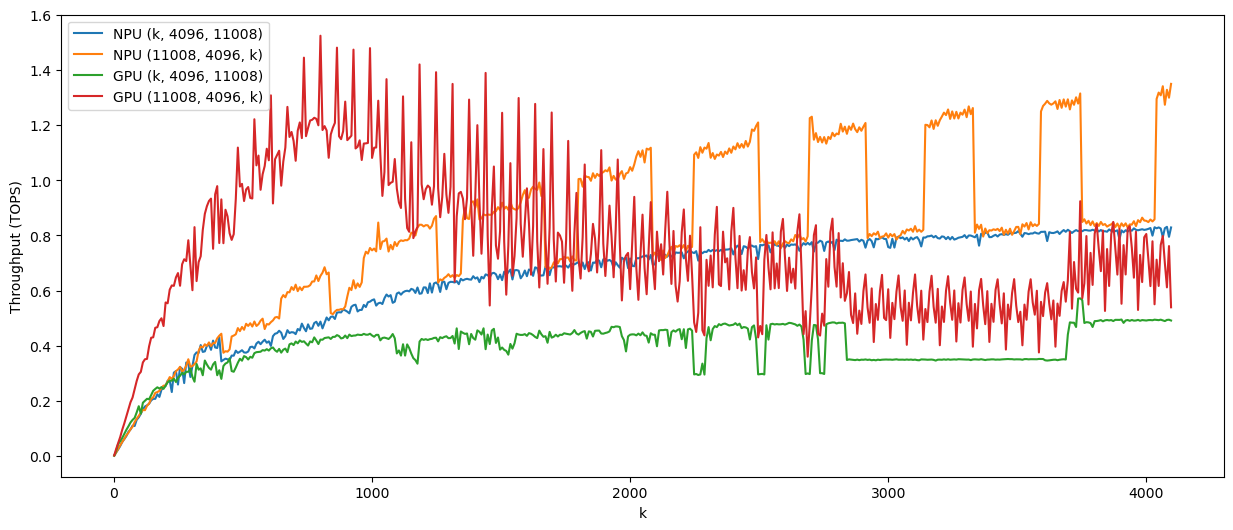

In [ ]:
npy_y1 = [d[2] for d in npu_data3]
npy_y2 = [d[2] for d in npu_data4]
gpu_y1 = [d[2] for d in gpu_data3]
gpu_y2 = [d[2] for d in gpu_data4]

fig, ax = plt.subplots(figsize=(15, 6), dpi=100)
ax.plot(x, npy_y1, label='NPU (k, 4096, 11008)')
ax.plot(x, npy_y2, label='NPU (11008, 4096, k)')
ax.plot(x, gpu_y1, label='GPU (k, 4096, 11008)')
ax.plot(x, gpu_y2, label='GPU (11008, 4096, k)')

ax.set_xlabel('k')
ax.set_ylabel('Throughput (TOPS)')
ax.legend()
plt.show()
